In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# 1. Drop the unnecessary index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Rename 'y' to 'diagnosis' so it makes clear sense
df = df.rename(columns={'y': 'diagnosis'})

# 3. Check the values inside 'diagnosis' to see how they are formatted
print("Unique values in diagnosis:", df['diagnosis'].unique())

# 4. Display the first few rows
df.head()

Unique values in diagnosis: ['B' 'M']


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,diagnosis
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [3]:
print(df.columns)

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')


In [5]:
# Map 'M' to 1 and 'B' to 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Verify the changes and check for any missing values across the data
print("Updated Unique values in diagnosis:", df['diagnosis'].unique())
print("Total missing values in dataset:", df.isnull().sum().sum())

Updated Unique values in diagnosis: [0 1]
Total missing values in dataset: 0


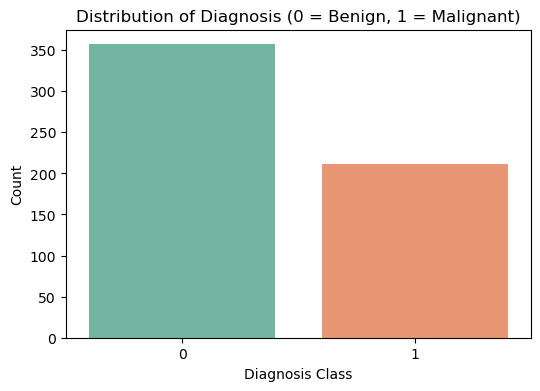

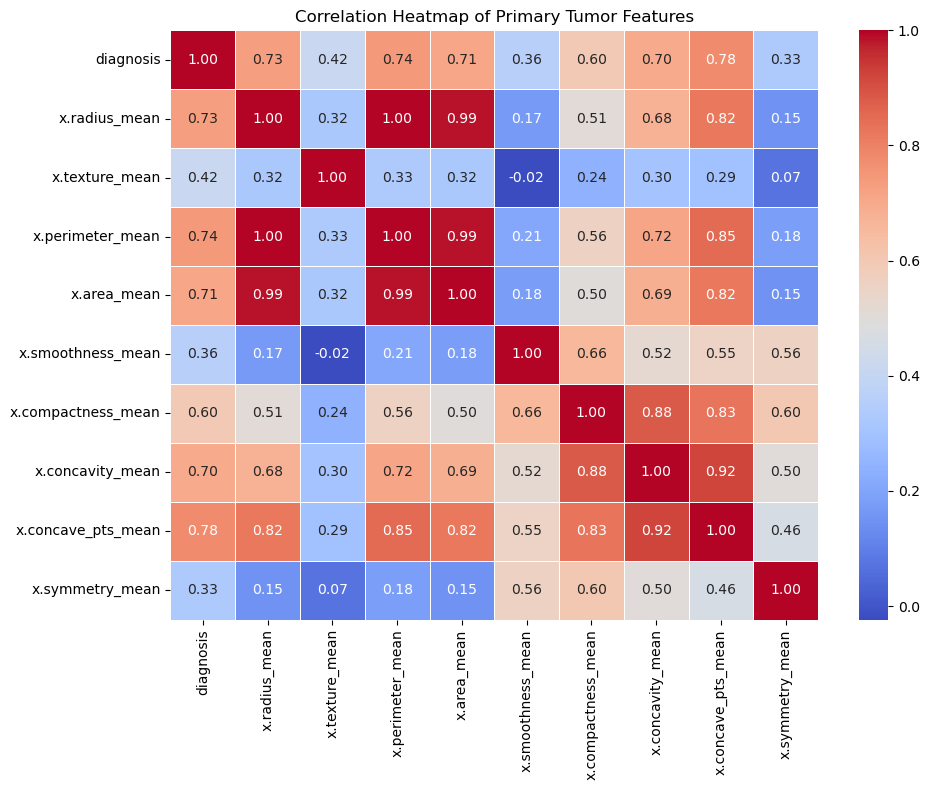

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make sure inline plotting is enabled
%matplotlib inline

# 1. Target Class Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Distribution of Diagnosis (0 = Benign, 1 = Malignant)')
plt.xlabel('Diagnosis Class')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap (Let's select the first 10 core features to keep it clear and legible)
core_features = ['diagnosis', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 
                 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 
                 'x.concave_pts_mean', 'x.symmetry_mean']

plt.figure(figsize=(10, 8))
sns.heatmap(df[core_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Primary Tumor Features')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate features (X) and target label (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 2. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize and scale the feature matrices
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling complete!")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Data splitting and scaling complete!
Training set shape: (455, 30)
Testing set shape: (114, 30)


In [9]:
# --- Model 1: Logistic Regression ---
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# --- Model 2: Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# --- PERFORMANCE EVALUATION BREAKDOWN ---
print("==============================================")
print(f"🏆 LOGISTIC REGRESSION ACCURACY: {accuracy_score(y_test, lr_pred) * 100:.2f}%")
print("==============================================")
print(classification_report(y_test, lr_pred))

print("\n==============================================")
print(f"🏆 RANDOM FOREST ACCURACY: {accuracy_score(y_test, rf_pred) * 100:.2f}%")
print("==============================================")
print(classification_report(y_test, rf_pred))

🏆 LOGISTIC REGRESSION ACCURACY: 96.49%
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


🏆 RANDOM FOREST ACCURACY: 95.61%
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [11]:
import pickle

# 1. Save the trained Random Forest model
with open('cancer_model.pkl', 'wb') as model_file:
    pickle.dump(rf_model, model_file)

# 2. Save the trained StandardScaler object
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Success! Both 'cancer_model.pkl' and 'scaler.pkl' have been saved to your project folder.")

Success! Both 'cancer_model.pkl' and 'scaler.pkl' have been saved to your project folder.
